In [17]:
import h5py
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.constants import physical_constants
ALPHA = physical_constants["fine-structure constant"][0]

mpl.rcParams["figure.figsize"] = (6,5)
mpl.rcParams["font.family"] = "Helvetica"
mpl.rcParams["font.size"] = 14

mpl.rcParams["xtick.direction"] = "in"
mpl.rcParams["ytick.direction"] = "in"
mpl.rcParams["xtick.top"] = True
mpl.rcParams["ytick.right"] = True
mpl.rcParams["xtick.minor.visible"] = True
mpl.rcParams["ytick.minor.visible"] = True

mpl.rcParams["legend.frameon"] = False

sns.set_palette("deep")

In [2]:
# --- Load cross section tables ---
with h5py.File("../data/PhotonScatter_total.h5", "r") as hf:
    s = hf["s"][:]
    sigma_unpol = hf["unpolarized"][:]
    sigma_polarised = {
        key: hf["polarized_"+key][:] for key in ["++++", "+++-", "++--"]
    }

In [18]:
# --- Linear Breit-Wheeler cross section ---
@np.vectorize
def breit_wheeler(s):
    if s < 4.0:
        return 0.0

    beta = np.sqrt(1.0 - 4.0 / s)
    logterm = np.log( (1.0 + beta) / (1.0 - beta) )

    sigma = -2.0 * beta * (2.0 - beta**2) + (3.0 - beta**4) * logterm
    sigma *= (np.pi / 2.0) * ALPHA**2 * (1.0 - beta**2)
    return sigma

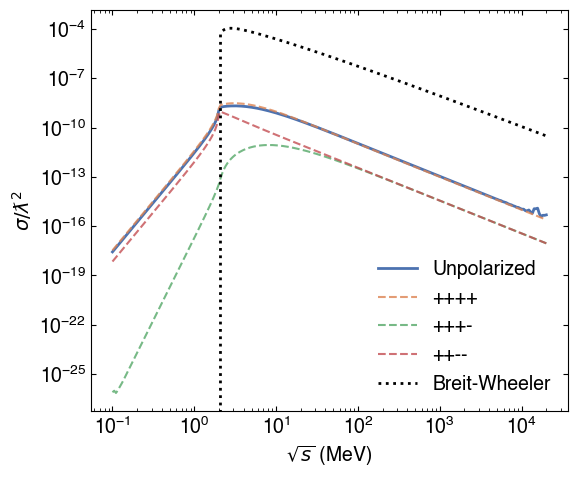

In [20]:
# --- Plot total cross sections ---
fig, ax = plt.subplots()
s_sqrt = np.sqrt(s)
ax.loglog(s_sqrt, sigma_unpol, label="Unpolarized", linewidth=2)
for key, sigma in sigma_polarised.items():
    ax.loglog(s_sqrt, sigma, "--", label=f"{key}", alpha=0.8)

ax.loglog(s_sqrt, breit_wheeler(s), label="Breit-Wheeler", lw=2, color="black", ls=":")

ax.set_xlabel(r"$\sqrt{s}$ (MeV)")
ax.set_ylabel(r"$\sigma / \lambdabar^2$")
ax.legend()

fig.savefig("cross_sections.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()